In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

In [2]:
df_raw = pd.read_csv('weatherHistory.csv')

print(f"Shape          : {df_raw.shape}  ({df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns)")
print(f"Columns        : {list(df_raw.columns)}")
print()
print("First 10 rows:")
df_raw.head(10)

Shape          : (96453, 12)  (96,453 rows × 12 columns)
Columns        : ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

First 10 rows:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [3]:
# Parse datetime and sort
df_raw['Formatted Date'] = pd.to_datetime(df_raw['Formatted Date'], utc=True)
df_raw = df_raw.sort_values('Formatted Date').reset_index(drop=True)

print(f"Date range : {df_raw['Formatted Date'].min().date()}  →  {df_raw['Formatted Date'].max().date()}")
print(f"Duration   : ~{(df_raw['Formatted Date'].max() - df_raw['Formatted Date'].min()).days} days ({(df_raw['Formatted Date'].max() - df_raw['Formatted Date'].min()).days//365} years)")

print("\nData Types:")
print(df_raw.dtypes)

print("\nBasic Statistics:")
df_raw.describe()

Date range : 2005-12-31  →  2016-12-31
Duration   : ~4017 days (11 years)

Data Types:
Formatted Date              datetime64[ns, UTC]
Summary                                  object
Precip Type                              object
Temperature (C)                         float64
Apparent Temperature (C)                float64
Humidity                                float64
Wind Speed (km/h)                       float64
Wind Bearing (degrees)                  float64
Visibility (km)                         float64
Loud Cover                              float64
Pressure (millibars)                    float64
Daily Summary                            object
dtype: object

Basic Statistics:


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


Missing Values:
             Count  Percentage (%)
Precip Type    517           0.536


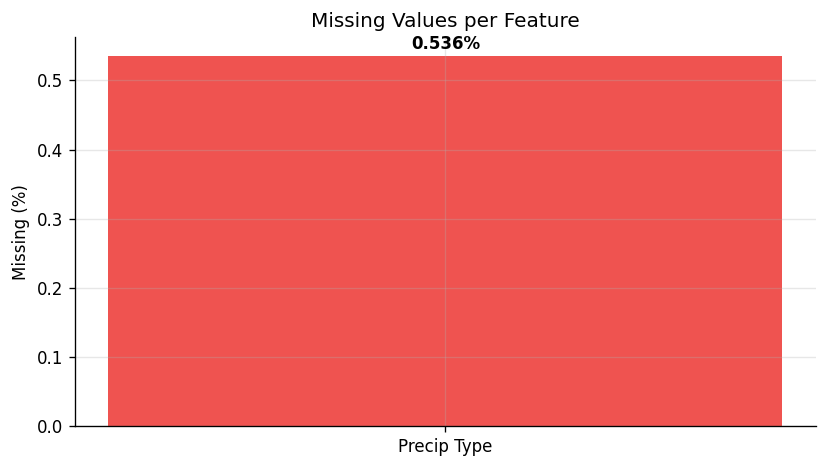


Note: Only 'Precip Type' has 517 missing values (~0.5%) — it is a categorical column and will be excluded from our model features.


In [4]:
# ── Missing Value Analysis ──
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]

print("Missing Values:")
print(missing_df)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(missing_df.index, missing_df['Percentage (%)'], color='#EF5350')
for bar, val in zip(bars, missing_df['Percentage (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Missing Values per Feature', fontsize=12)
ax.set_ylabel('Missing (%)')
plt.tight_layout()
plt.show()

print(f"\nNote: Only 'Precip Type' has {missing_df.loc['Precip Type','Count']} missing values (~{missing_df.loc['Precip Type','Percentage (%)']:.1f}%) — it is a categorical column and will be excluded from our model features.")

In [5]:
# ── Aggregate hourly → daily (mean per day) ──
df_raw['date'] = df_raw['Formatted Date'].dt.date

daily = df_raw.groupby('date').agg(
    temperature   = ('Temperature (C)',       'mean'),
    humidity      = ('Humidity',               'mean'),
    wind_speed    = ('Wind Speed (km/h)',       'mean'),
    pressure      = ('Pressure (millibars)',    'mean'),
    visibility    = ('Visibility (km)',         'mean'),
    apparent_temp = ('Apparent Temperature (C)','mean')
).reset_index()

daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(f"Daily dataset shape: {daily.shape}  ({daily.shape[0]} days)")
print(f"Date range: {daily['date'].min().date()} → {daily['date'].max().date()}")
daily.head(10)

Daily dataset shape: (4019, 7)  (4019 days)
Date range: 2005-12-31 → 2016-12-31


,date,temperature,humidity,wind_speed,pressure,visibility,apparent_temp
0,2005-12-31,0.577778,0.890000,17.114300,1016.660000,9.982000,-4.050000
1,2006-01-01,4.075000,0.817083,21.229192,1011.985000,11.348487,-0.174537
2,2006-01-02,5.263194,0.847083,17.824713,1010.384167,8.492079,1.808796
3,2006-01-03,2.340509,0.897083,7.726658,1021.170833,9.223958,0.445370
4,2006-01-04,2.251852,0.906667,12.152817,981.770833,8.352546,-0.663194
5,2006-01-05,2.703935,0.951250,8.991179,935.873750,4.308092,0.445833
6,2006-01-06,2.550463,0.945833,5.729588,1023.645833,4.635458,1.231250
7,2006-01-07,0.877083,0.935833,6.589596,1030.223750,4.585817,-0.749769
8,2006-01-08,-1.231713,0.868750,5.397525,1035.481250,8.694671,-2.805093
9,2006-01-09,-1.693287,0.792500,5.113762,1034.542500,8.891225,-2.840046


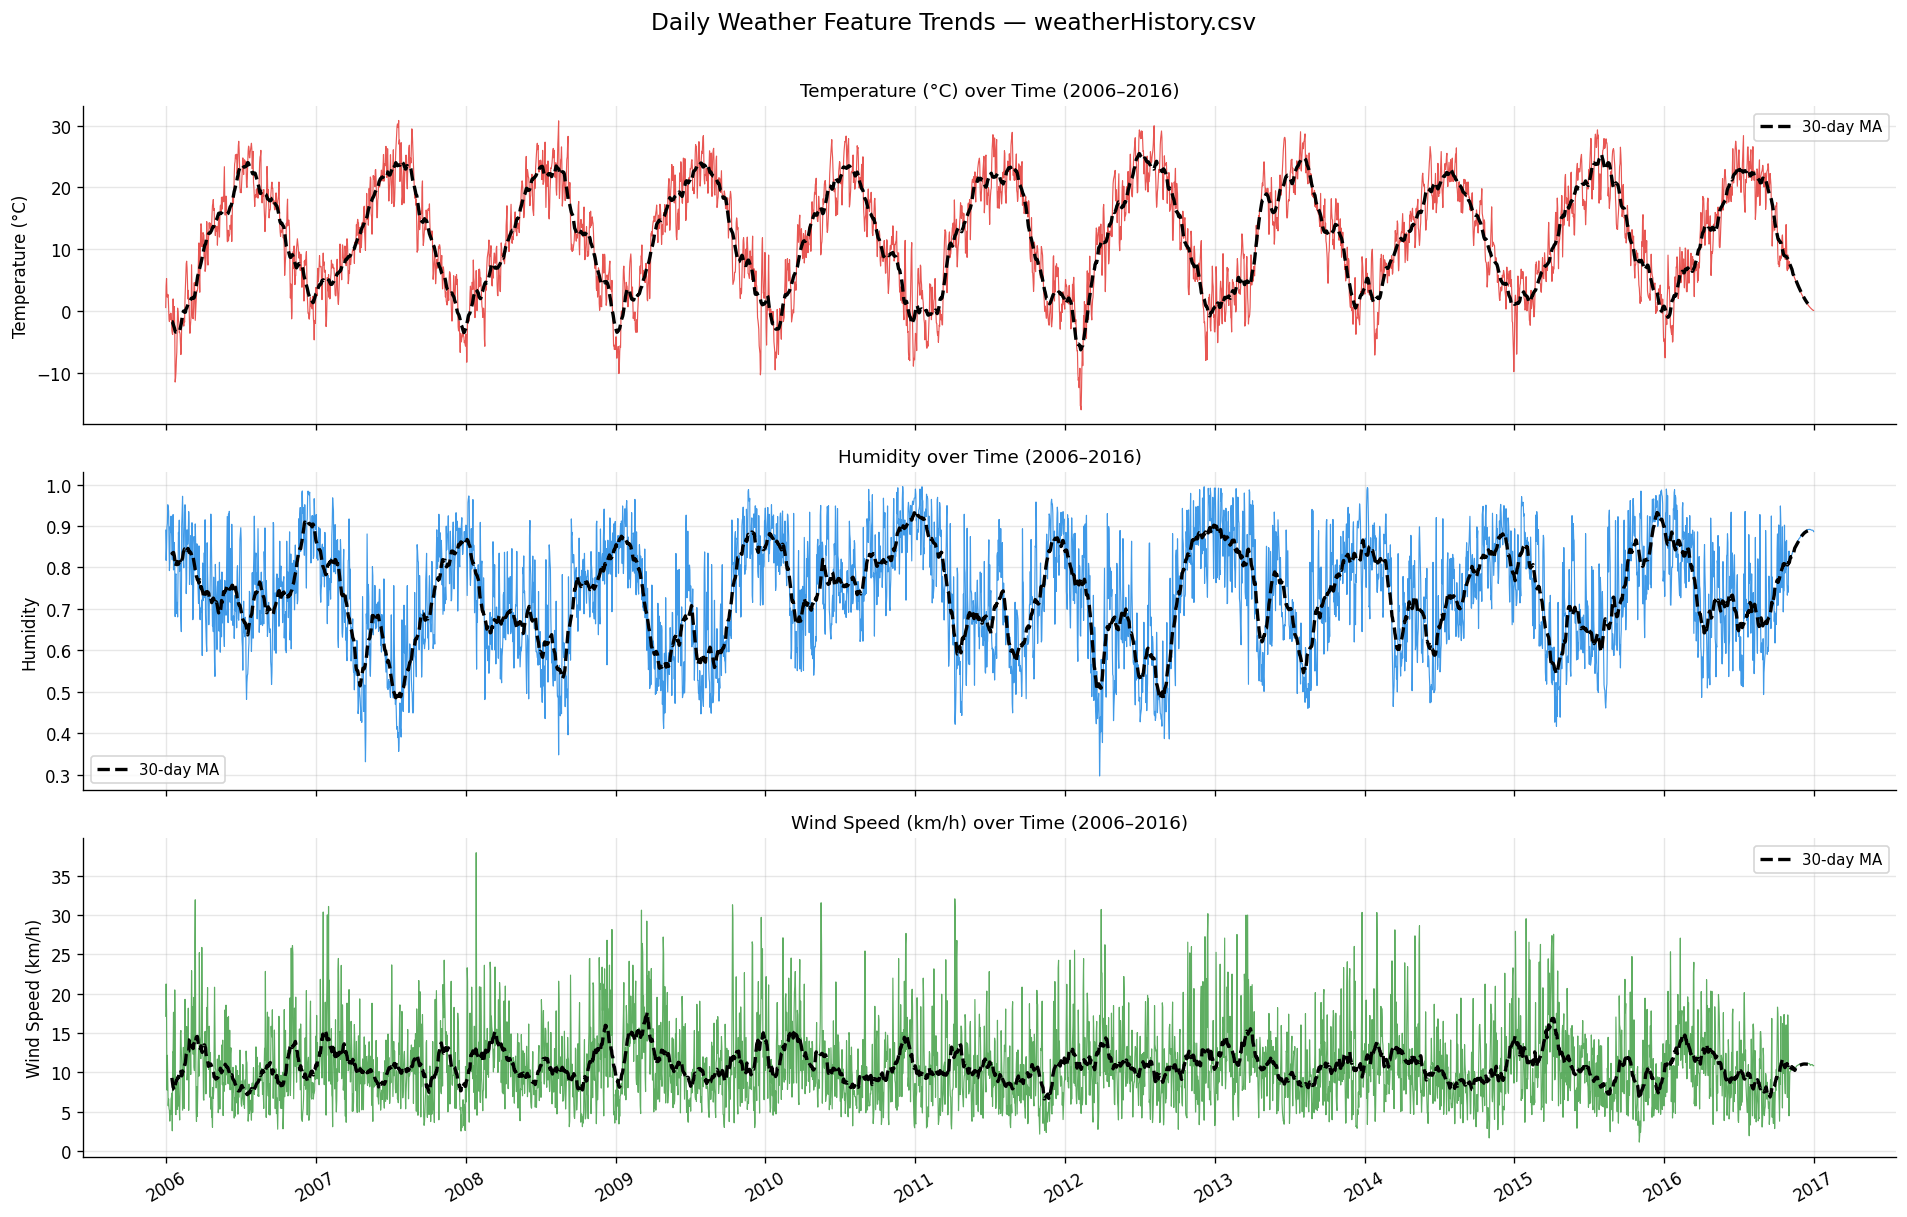

In [6]:
# ── Temperature Trend over Time ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

plot_configs = [
    ('temperature', 'Temperature (°C)',    '#E53935'),
    ('humidity',    'Humidity',            '#1E88E5'),
    ('wind_speed',  'Wind Speed (km/h)',   '#43A047'),
]

for ax, (col, ylabel, color) in zip(axes, plot_configs):
    ax.plot(daily['date'], daily[col], color=color, lw=0.7, alpha=0.85)
    ax.plot(daily['date'], daily[col].rolling(30, center=True).mean(),
            color='black', lw=2, linestyle='--', label='30-day MA')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel} over Time (2006–2016)', fontsize=11)
    ax.legend(fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30)
plt.suptitle('Daily Weather Feature Trends — weatherHistory.csv', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

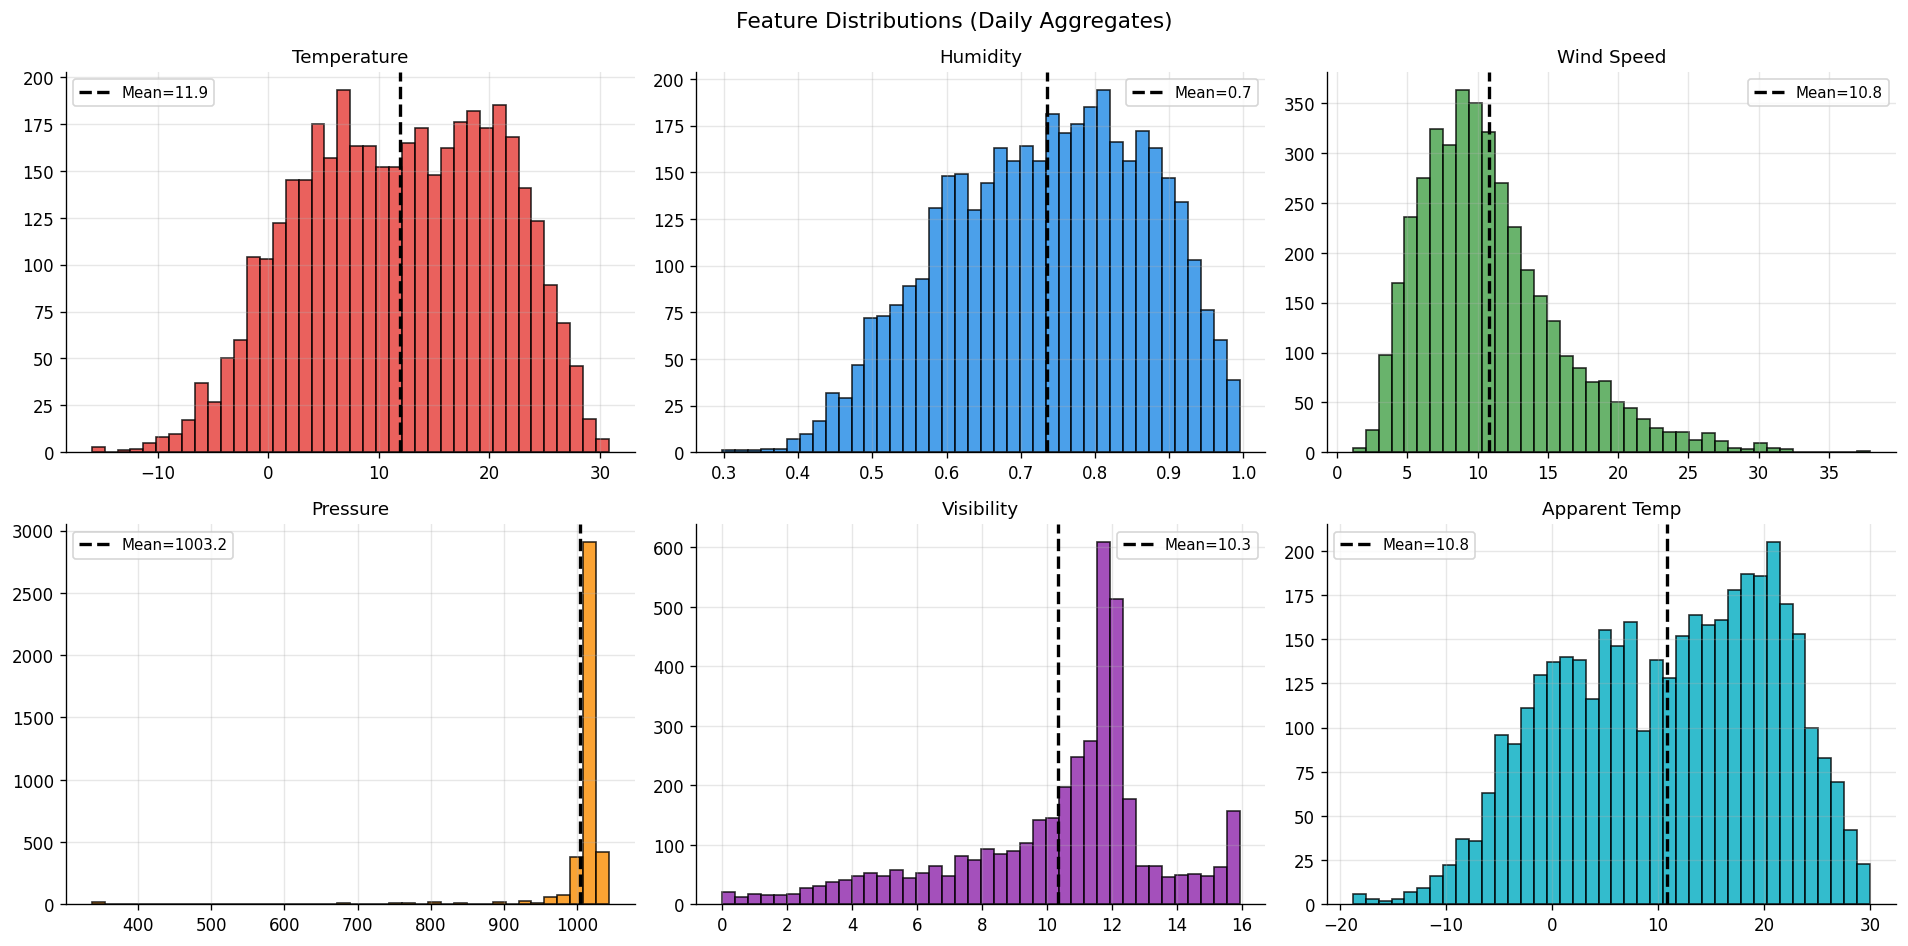

In [7]:
# ── Distribution plots ──
num_cols = ['temperature', 'humidity', 'wind_speed', 'pressure', 'visibility', 'apparent_temp']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA','#00ACC1']

for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(daily[col], bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(daily[col].mean(), color='black', lw=2, linestyle='--',
               label=f'Mean={daily[col].mean():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions (Daily Aggregates)', fontsize=13)
plt.tight_layout()
plt.show()

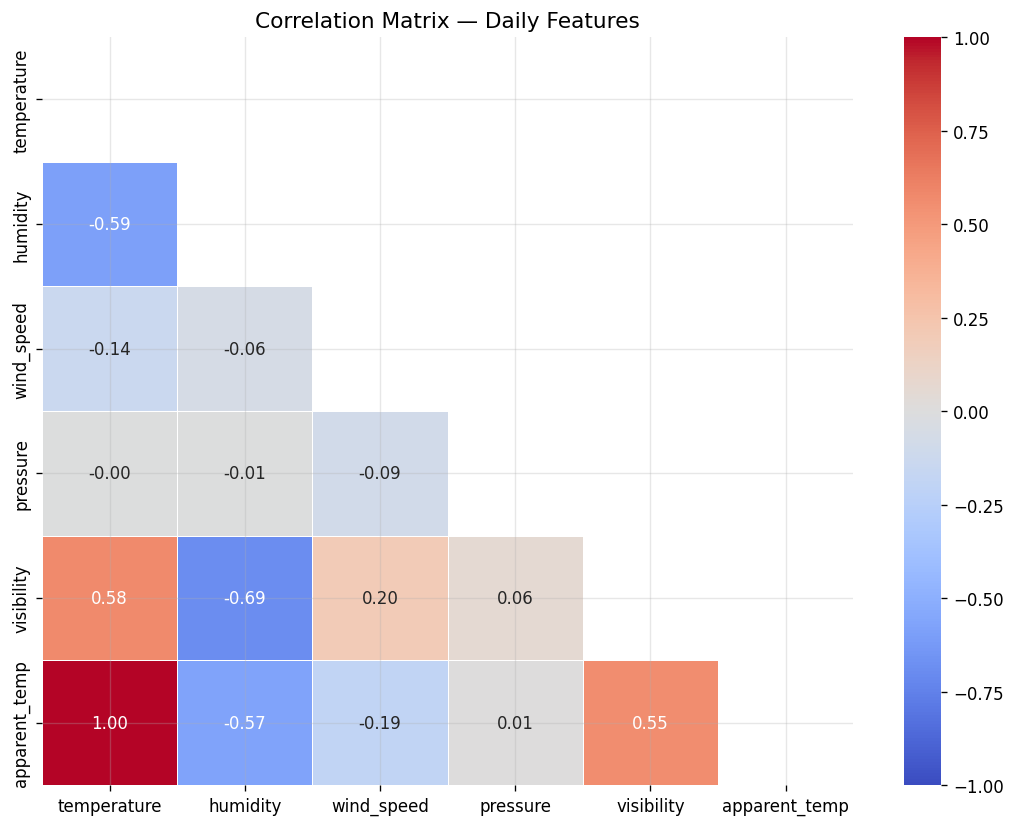

Correlation with Temperature:
apparent_temp    0.995746
visibility       0.575751
pressure        -0.000511
wind_speed      -0.139583
humidity        -0.590931
Name: temperature, dtype: float64


In [8]:
# ── Correlation Heatmap ──
plt.figure(figsize=(9, 7))
corr = daily[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Correlation Matrix — Daily Features', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation with Temperature:")
print(corr['temperature'].drop('temperature').sort_values(ascending=False))

In [9]:
# ── Features selected for the model ──
FEATURES = ['temperature', 'humidity', 'wind_speed']  # core features as per assignment

# Step 1: Handle missing values (forward-fill then back-fill)
before_null = daily[FEATURES].isnull().sum().sum()
daily[FEATURES] = daily[FEATURES].fillna(method='ffill').fillna(method='bfill')
after_null  = daily[FEATURES].isnull().sum().sum()
print(f"Missing values before: {before_null}  →  after: {after_null}")

# Step 2: Normalize using MinMaxScaler
scaler        = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))   # for inverse-transforming predictions

scaled_data = scaler.fit_transform(daily[FEATURES])
scaler_target.fit(daily[['temperature']])

print(f"Scaled data  — min: {scaled_data.min():.4f}  max: {scaled_data.max():.4f}")
print(f"\nFeatures used : {FEATURES}")
print(f"Total daily records : {len(daily)}")

Missing values before: 0  →  after: 0
Scaled data  — min: 0.0000  max: 1.0000

Features used : ['temperature', 'humidity', 'wind_speed']
Total daily records : 4019


In [10]:
# ── Step 3: Create sliding-window sequences ──
SEQ_LEN   = 10    # 10-day lookback (within assignment range 7–14)
N_FEATURES = len(FEATURES)

def create_sequences(data, seq_len, target_col=0):
    """Returns X (samples, seq_len, features) and y (next-day temperature)."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, target_col])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data, SEQ_LEN)

print(f"Lookback window  : {SEQ_LEN} days")
print(f"Total sequences  : {X_all.shape[0]:,}")
print(f"X shape          : {X_all.shape}  → (samples, timesteps, features)")
print(f"y shape          : {y_all.shape}")

Lookback window  : 10 days
Total sequences  : 4,009
X shape          : (4009, 10, 3)  → (samples, timesteps, features)
y shape          : (4009,)


In [11]:
# ── Step 4: Train / Validation / Test split (70 / 15 / 15) ──
n         = len(X_all)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_all[:train_end],          y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end],   y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],            y_all[val_end:]

test_dates = daily['date'].iloc[val_end + SEQ_LEN:].reset_index(drop=True)

print(f"Training   : {X_train.shape[0]:>5,} samples  ({X_train.shape[0]/n*100:.1f}%)")
print(f"Validation : {X_val.shape[0]:>5,} samples  ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test       : {X_test.shape[0]:>5,} samples  ({X_test.shape[0]/n*100:.1f}%)")

Training   : 2,806 samples  (70.0%)
Validation :   601 samples  (15.0%)
Test       :   602 samples  (15.0%)


In [12]:
def build_simple_rnn(seq_len, n_features, rnn_units=64, dropout=0.2, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.SimpleRNN(rnn_units, activation='tanh',
                         return_sequences=False, name='SimpleRNN'),
        layers.Dropout(dropout, name='Dropout'),
        layers.Dense(32, activation='relu', name='Dense_hidden'),
        layers.Dense(1,  activation='linear', name='Output')
    ], name='SimpleRNN_TemperatureForecaster')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

model = build_simple_rnn(SEQ_LEN, N_FEATURES)
model.summary()

Model: "SimpleRNN_TemperatureForecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ SimpleRNN (SimpleRNN)                │ (None, 64)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_hidden (Dense)                 │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS     = 100
BATCH_SIZE = 32

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_rnn_weather.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch          : {best_epoch}")
print(f"Best val_loss (MSE) : {min(history.history['val_loss']):.6f}")

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0408 - mae: 0.1347 - val_loss: 0.0043 - val_mae: 0.0521 - learning_rate: 0.0010
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0098 - mae: 0.0788 - val_loss: 0.0036 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - mae: 0.0681 - val_loss: 0.0032 - val_mae: 0.0459 - learning_rate: 0.0010
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 - mae: 0.0635 - val_loss: 0.0036 - val_mae: 0.0483 - learning_rate: 0.0010
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0059 - mae: 0.0611 - val_loss: 0.0028 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 - mae: 0.0574 - val_loss: 0.0039 - val_mae: 0.0511 - learning_rate: 0.0010
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - mae: 0.0580 - val_loss: 0.0024 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 8/100


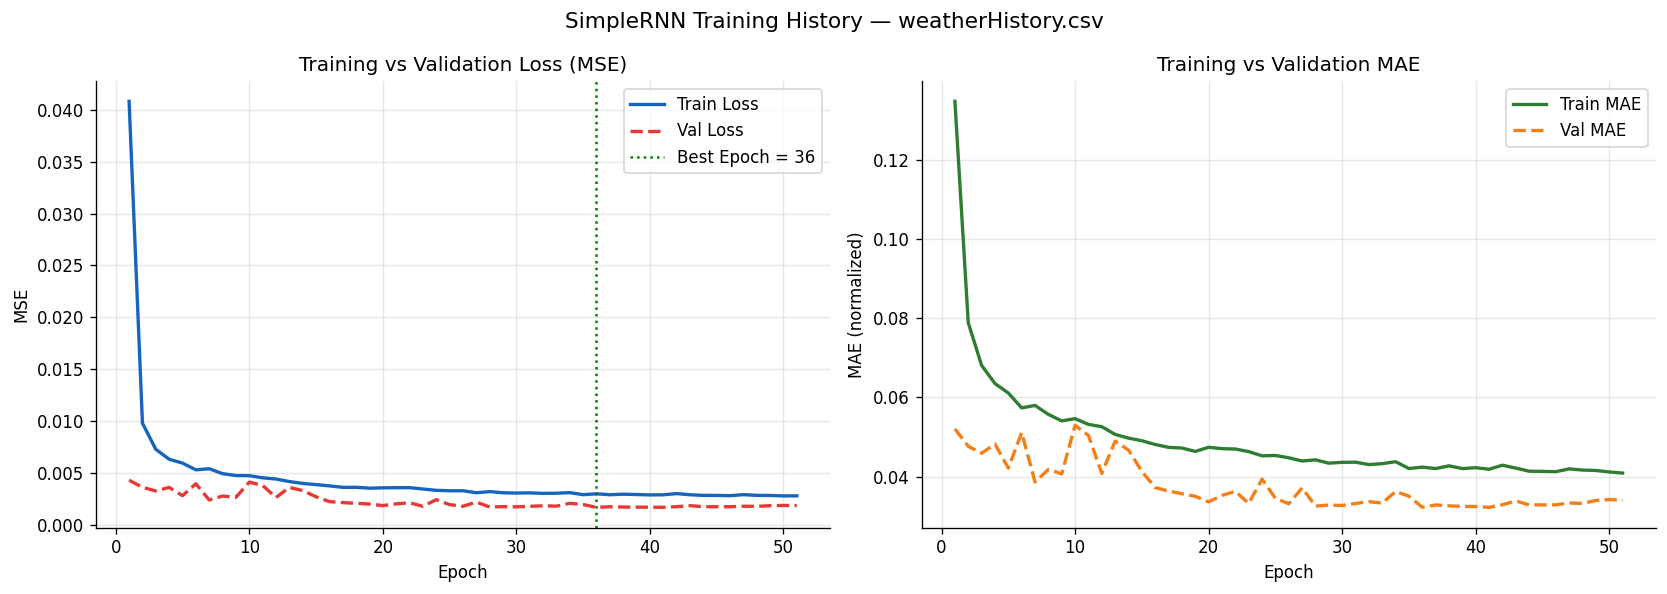

In [14]:
# ── Training vs Validation Loss Curves ──
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history['loss'],     color='#1565C0', lw=2, label='Train Loss')
axes[0].plot(epochs_range, history.history['val_loss'], color='#E53935', lw=2, linestyle='--', label='Val Loss')
axes[0].axvline(best_epoch, color='green', lw=1.5, linestyle=':', label=f'Best Epoch = {best_epoch}')
axes[0].set_title('Training vs Validation Loss (MSE)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(epochs_range, history.history['mae'],     color='#2E7D32', lw=2, label='Train MAE')
axes[1].plot(epochs_range, history.history['val_mae'], color='#F57F17', lw=2, linestyle='--', label='Val MAE')
axes[1].set_title('Training vs Validation MAE', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (normalized)')
axes[1].legend()

plt.suptitle('SimpleRNN Training History — weatherHistory.csv', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
best_model = keras.models.load_model('best_rnn_weather.keras')

# Predict and inverse-transform back to °C
y_pred_sc = best_model.predict(X_test, verbose=0).flatten()
y_pred    = scaler_target.inverse_transform(y_pred_sc.reshape(-1,1)).flatten()
y_true    = scaler_target.inverse_transform(y_test.reshape(-1,1)).flatten()

# ── Metrics ──
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("\n" + "="*50)
print("   SimpleRNN — Test Set Performance (°C)")
print("="*50)
print(f"   MSE  (Mean Squared Error)      : {mse:.4f}")
print(f"   RMSE (Root Mean Squared Error) : {rmse:.4f} °C")
print(f"   MAE  (Mean Absolute Error)     : {mae:.4f} °C")
print(f"   R²   Score                     : {r2:.4f}")
print("="*50)


   SimpleRNN — Test Set Performance (°C)
   MSE  (Mean Squared Error)      : 3.9107
   RMSE (Root Mean Squared Error) : 1.9776 °C
   MAE  (Mean Absolute Error)     : 1.5099 °C
   R²   Score                     : 0.9454


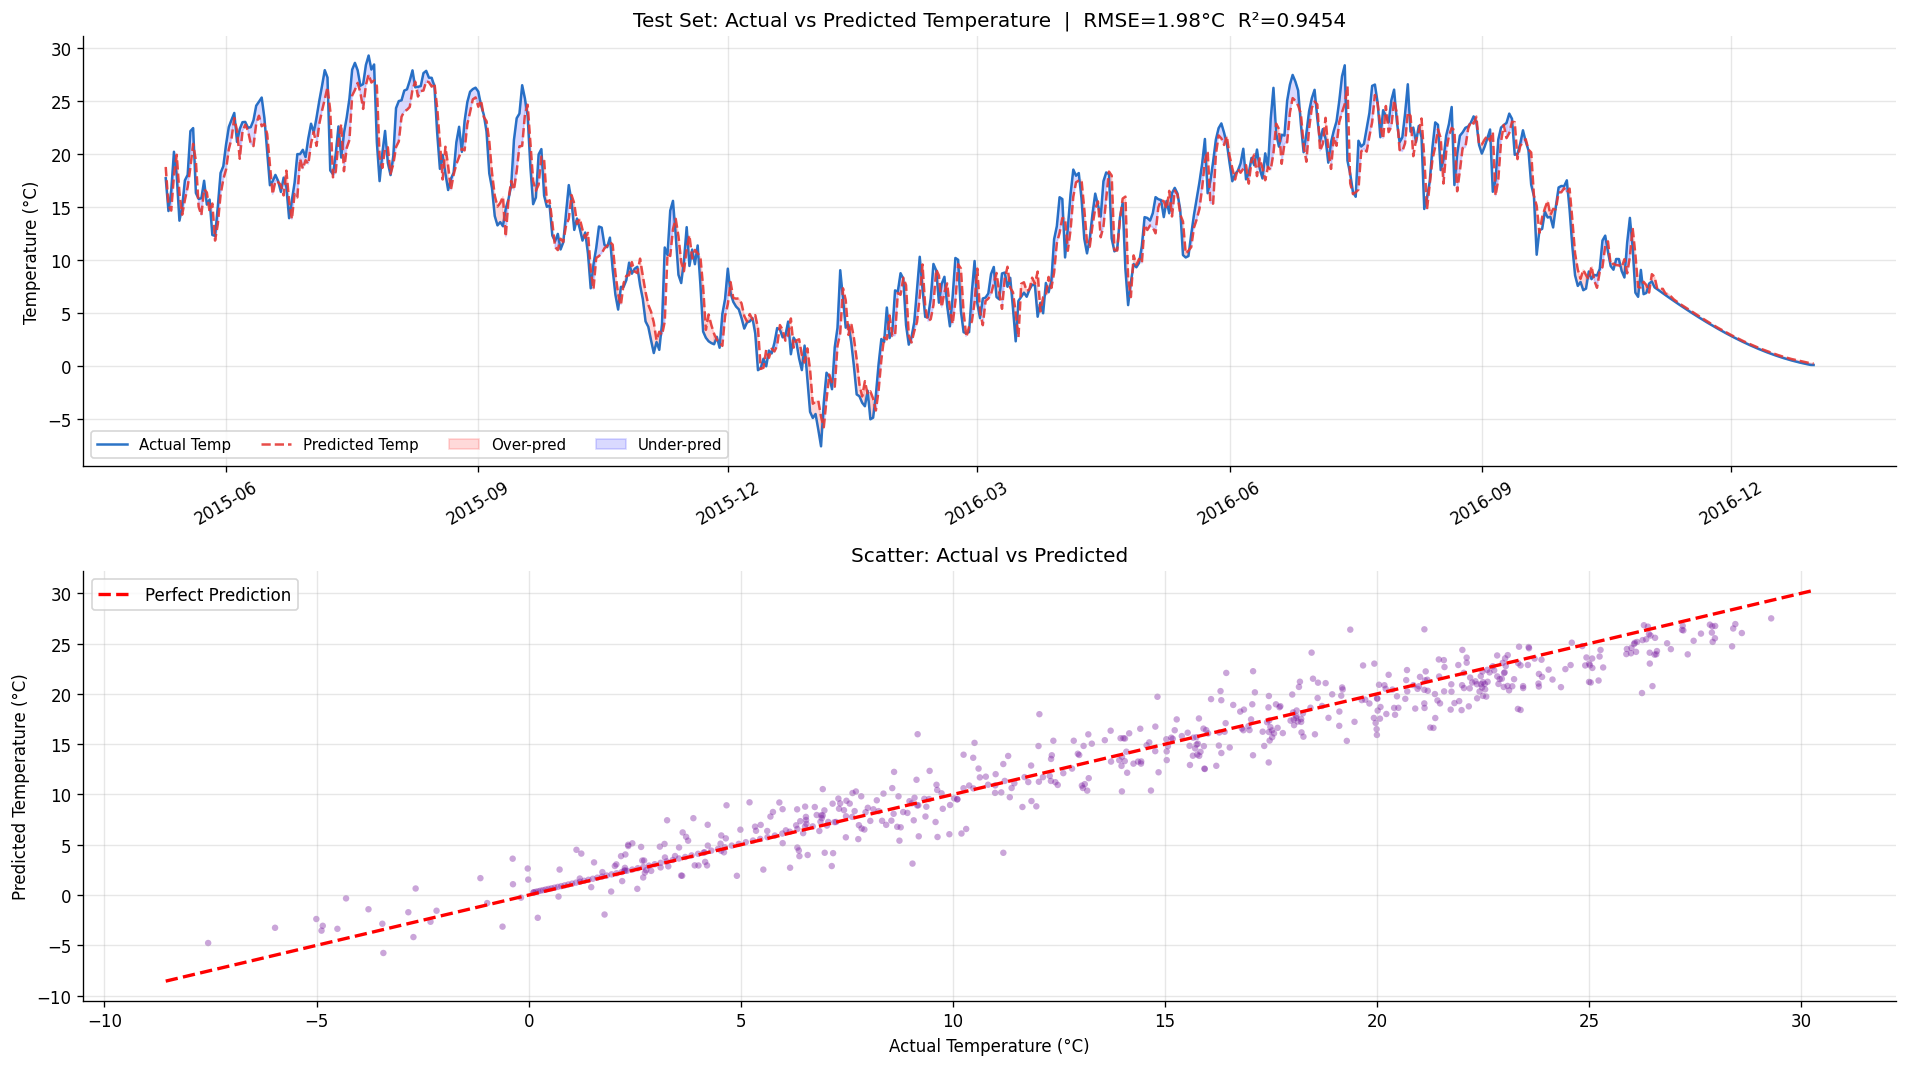

In [16]:
# ── Predicted vs Actual — Time Series ──
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

plot_dates = test_dates[:len(y_true)]

axes[0].plot(plot_dates, y_true, color='#1565C0', lw=1.5, alpha=0.9, label='Actual Temp')
axes[0].plot(plot_dates, y_pred, color='#E53935', lw=1.5, alpha=0.9,
             linestyle='--', label='Predicted Temp')
axes[0].fill_between(plot_dates, y_true, y_pred,
                     where=(y_pred >= y_true), alpha=0.15, color='red',   label='Over-pred')
axes[0].fill_between(plot_dates, y_true, y_pred,
                     where=(y_pred <  y_true), alpha=0.15, color='blue',  label='Under-pred')
axes[0].set_title(f'Test Set: Actual vs Predicted Temperature  |  RMSE={rmse:.2f}°C  R²={r2:.4f}',
                  fontsize=12)
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(ncol=4, fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].scatter(y_true, y_pred, alpha=0.4, color='#7B1FA2', s=15, edgecolors='none')
lims = [min(y_true.min(), y_pred.min())-1, max(y_true.max(), y_pred.max())+1]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title('Scatter: Actual vs Predicted', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

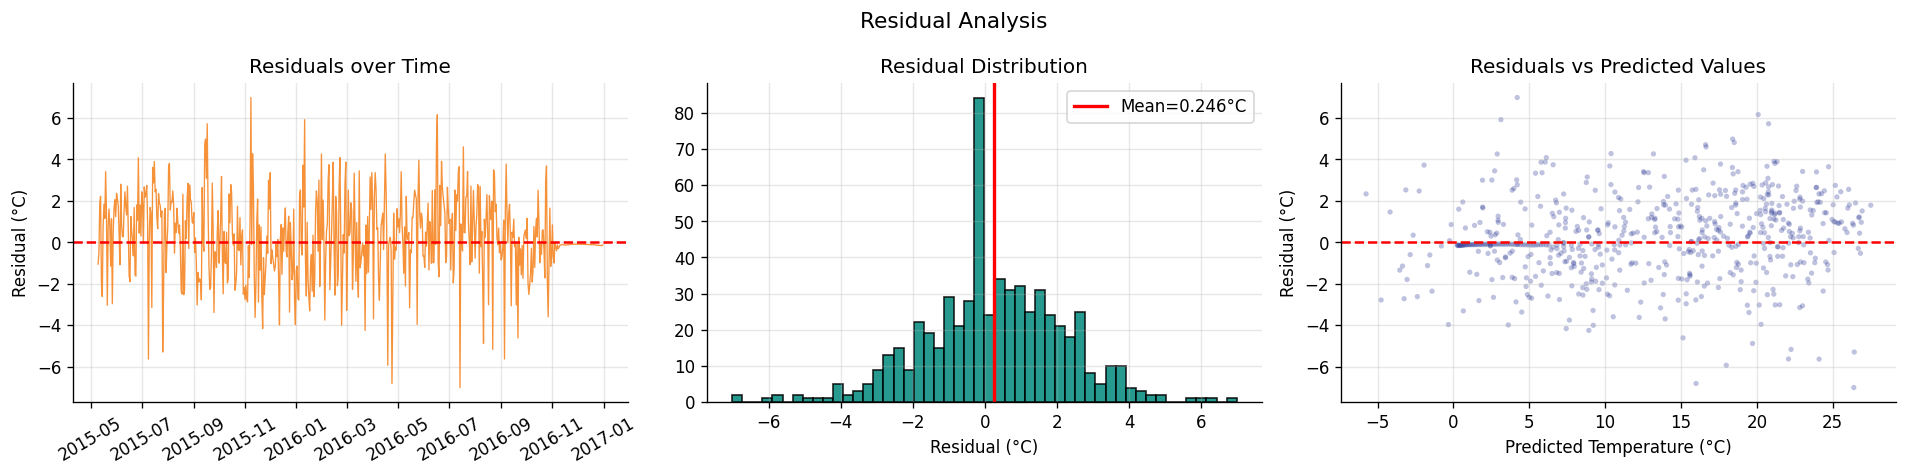

Residual stats — Mean: 0.2457°C  |  Std: 1.9622°C


In [17]:
# ── Residual Analysis ──
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(plot_dates, residuals, color='#F57F17', lw=0.8, alpha=0.85)
axes[0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_title('Residuals over Time')
axes[0].set_ylabel('Residual (°C)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].hist(residuals, bins=50, color='#00897B', edgecolor='black', alpha=0.85)
axes[1].axvline(residuals.mean(), color='red', lw=2, label=f'Mean={residuals.mean():.3f}°C')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (°C)')
axes[1].legend()

axes[2].scatter(y_pred, residuals, alpha=0.3, color='#283593', s=10, edgecolors='none')
axes[2].axhline(0, color='red', lw=1.5, linestyle='--')
axes[2].set_title('Residuals vs Predicted Values')
axes[2].set_xlabel('Predicted Temperature (°C)')
axes[2].set_ylabel('Residual (°C)')

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Residual stats — Mean: {residuals.mean():.4f}°C  |  Std: {residuals.std():.4f}°C")

In [18]:
FORECAST_DAYS = 7

# Seed with the last SEQ_LEN rows of the scaled dataset
last_window    = scaled_data[-SEQ_LEN:].copy()
forecast_sc    = []

for _ in range(FORECAST_DAYS):
    inp  = last_window.reshape(1, SEQ_LEN, N_FEATURES)
    pred = best_model.predict(inp, verbose=0)[0, 0]
    forecast_sc.append(pred)
    # Shift window: carry forward last humidity & wind_speed
    new_row    = last_window[-1].copy()
    new_row[0] = pred
    last_window = np.vstack([last_window[1:], new_row])

# Inverse-transform
forecast_temps = scaler_target.inverse_transform(
    np.array(forecast_sc).reshape(-1, 1)
).flatten()

last_date      = daily['date'].max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

forecast_df = pd.DataFrame({
    'Date': forecast_dates.strftime('%Y-%m-%d'),
    'Predicted Temp (°C)': forecast_temps.round(2)
})

print("7-Day Temperature Forecast:")
print("-" * 35)
print(forecast_df.to_string(index=False))

7-Day Temperature Forecast:
-----------------------------------
      Date  Predicted Temp (°C)
2017-01-01                 0.24
2017-01-02                 0.35
2017-01-03                 0.46
2017-01-04                 0.54
2017-01-05                 0.62
2017-01-06                 0.69
2017-01-07                 0.77


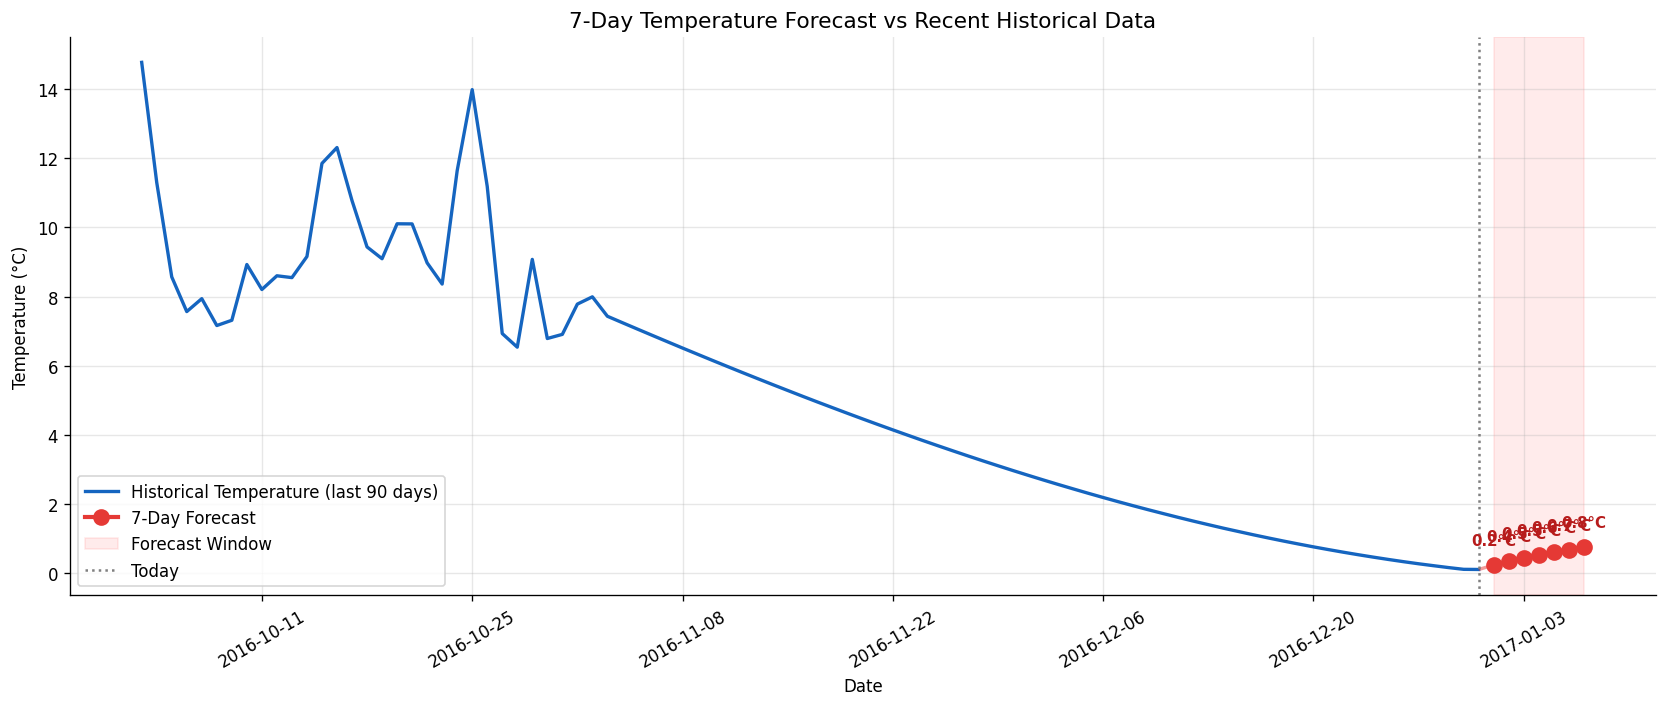

In [19]:
# ── Forecast vs Recent Historical ──
HISTORY_SHOW = 90
recent_dates = daily['date'].tail(HISTORY_SHOW)
recent_temps = daily['temperature'].tail(HISTORY_SHOW)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(recent_dates, recent_temps, color='#1565C0', lw=2,
        label='Historical Temperature (last 90 days)')

# Bridge line
ax.plot([recent_dates.iloc[-1], forecast_dates[0]],
        [recent_temps.iloc[-1], forecast_temps[0]],
        color='#E53935', lw=2, linestyle='--', alpha=0.5)

ax.plot(forecast_dates, forecast_temps,
        color='#E53935', lw=2.5, marker='o', markersize=9,
        label='7-Day Forecast')

ax.axvspan(forecast_dates[0], forecast_dates[-1],
           alpha=0.08, color='red', label='Forecast Window')
ax.axvline(last_date, color='gray', lw=1.5, linestyle=':', label='Today')

for d, t in zip(forecast_dates, forecast_temps):
    ax.annotate(f'{t:.1f}°C', xy=(d, t), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontsize=9, fontweight='bold', color='#B71C1C')

ax.set_title('7-Day Temperature Forecast vs Recent Historical Data', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
# ── Final Summary ──
print("=" * 52)
print("  FINAL MODEL PERFORMANCE SUMMARY (Test Set)")
print("=" * 52)
summary = pd.DataFrame({
    'Metric' : ['MSE',    'RMSE',   'MAE',   'R² Score'],
    'Value'  : [round(mse,4), round(rmse,4), round(mae,4), round(r2,4)],
    'Unit'   : ['°C²',   '°C',     '°C',    '—']
})
print(summary.to_string(index=False))

print()
print("=" * 52)
print("  7-DAY FORECAST")
print("=" * 52)
print(forecast_df.to_string(index=False))

  FINAL MODEL PERFORMANCE SUMMARY (Test Set)
  Metric  Value Unit
     MSE 3.9107  °C²
    RMSE 1.9776   °C
     MAE 1.5099   °C
R² Score 0.9454    —

  7-DAY FORECAST
      Date  Predicted Temp (°C)
2017-01-01                 0.24
2017-01-02                 0.35
2017-01-03                 0.46
2017-01-04                 0.54
2017-01-05                 0.62
2017-01-06                 0.69
2017-01-07                 0.77
